# Example: using `odil_wave` to solve the 2D wave equation.

`odil_wave` is a small package for solving the 2D forced wave equation using the Optimising a Discrete Loss framework.

The general procedure is:

- define a discretisation grid
- define a velocity model
- define the wavefield and finite difference operators
- define the loss and optimisation problem
- minimise the loss

First, let's define some parameters.

In [257]:
# discretisation parameters
nx = 100
ny = 100
space_order = 2
time_order = 2

# physical parameters
xmin, ymin = 0.0, 0.0           # m
xmax, ymax = 80.0, 80.0         # m
c_min, c_max = 1200.0, 1500.0   # ms-1
t_max = 0.07                    # s
cfl = 0.9

Now, we can define a `Grid`: the grid on which the wave equation is discretised.

In [258]:
from odil_wave import Grid
grid = Grid(nx=nx, ny=ny, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax, c_min=c_min, c_max=c_max, t_max=t_max, cfl_safety=cfl)

In [259]:
print(grid.summary)

Nx, Ny, Nt: 100, 100, 206
dx, dy, dt: 0.808080808m, 0.808080808m, 0.000341463s
CFL (at c_max = 1500.0):  0.896
x in [0.000, 80.000]m
y in [0.000, 80.000]m


The time discretisation is computed automatically from the spatial spec according to the CFL condition.

From a `Grid`, we can start to build the other components of the problem. First, let's build a velocity model.

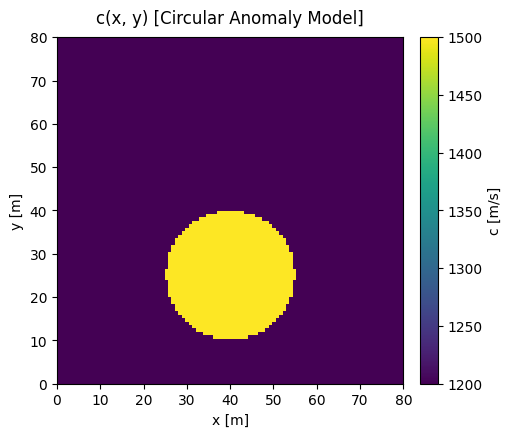

In [260]:
from odil_wave import OverDensityModel

model = OverDensityModel(grid, background_c=c_min, contrast=c_max-c_min, centre=(40.0, 25.0), radius=15)
ax = model.show()

Amplitude data can be represented by a `Wavefield` object:

In [261]:
from odil_wave import Wavefield
wavefield = Wavefield(grid=grid)

Amplitude data is initialised to zero by default.

To drive wave propagation, we need a source term. We can define sources using the `Sources` class. Sources can be placed in a ring, or using custom spatial position in (x, y) coordinates. Source injection is controlled by sinc interpolation, which is a way to represent a point source exactly on a discrete grid. 

If we define an array of `Receievers`, we can later extract discrete observations from the wavefield.

In [262]:
# source parameters
f0 = 120.0                   # Hz
src_loc = ((40.0, 50.0),)    # m

# receiver parameters
recv_locs = ((20.0, 25.0), (40.0, 15.0), (60.0, 40.0)) # m

In [263]:
from odil_wave.geometry import Sources, Receivers
source = Sources(grid, f0=f0, source_locs=src_loc)
receivers = Receivers(grid, receiver_locs=recv_locs)

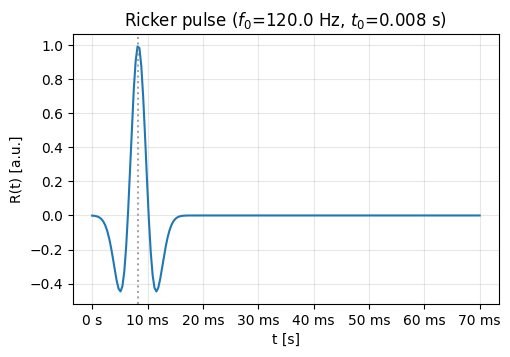

In [264]:
ax = source.plot_source_pulse()

These can be bundled into an `AcquisitionGeometry` object for convenience.

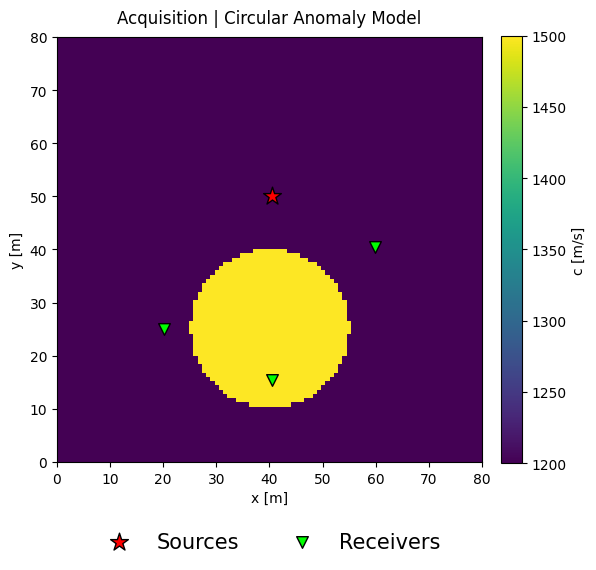

In [265]:
from odil_wave.geometry import AcquisitionGeometry
geom = AcquisitionGeometry(source, receivers)
ax = geom.show(model)

We can now move towards the physics of our problem. The discretisation scheme is controlled by operators of type `Operator` and there are a few options, but thankfully we can just specify the desired method order in time and space to a `WaveEquation` object and it will construct our operators along with objects that apply initial and boundary conditions. 

In [266]:
from odil_wave import WaveEquation

wave_eq = WaveEquation(wavefield, model, time_order=time_order, space_order=space_order)

To form a loss function, we can use a `ForwardLoss` object that should be configured by defining our `Problem`.

In [267]:
from odil_wave import Problem
problem = Problem(wave_eq=wave_eq, geometry=geom)

In [268]:
from odil_wave import ForwardLoss
loss = ForwardLoss(problem=problem)

Now, we can define our `Optimiser`. The suggested optimiser is the `GaussNewtonOptimiser`, which uses the ParaDiagII preconditioner and hardware parallelism to accelerate the solve. We also expose a `ScipyOptimiser` class, which is far slower but more configurable.

In [269]:
import os

# set number of cores here, defaults to total available
ncores = len(os.sched_getaffinity(0))

In [270]:
from odil_wave import GaussNewtonOptimiser
optimiser = GaussNewtonOptimiser(loss, outer_maxiter=2, outer_ftol=1e-12, outer_gtol=1e-10)

Let's try to sove this problem.

In [271]:
result = optimiser.minimise(n_workers=ncores)

Optimisation results are encapsulated by `SolveResult` objects, with a variety of fields.

In [272]:
result

   message: Gradient norm below outer_gtol
   success: True
       fun: 7.869397551448102e-36
         x: [ 0.000e+00  0.000e+00 ... -1.404e-10 -4.157e-11]
       nit: 2
        wf: Wavefield(grid=Grid(xmin=0.0, xmax=80.0, ymin=0.0, ymax=80.0, t_max=0.07, nx=100, ny=100, nt=206, c_min=1200.0, c_max=1500.0, cfl_safety=0.9, allow_unstable=False, dx=0.8080808080808081, dy=0.8080808080808081, dt=0.0003414634146341464, _extent=((0.0, 80.0), (0.0, 80.0))), _amplitude=array([[ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00],
                   [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00],
                   ...,
                   [-6.429e-10, -5.070e-10, ..., -9.000e-11, -3.459e-11],
                   [-5.250e-10, -4.028e-10, ..., -1.404e-10, -4.157e-11]],
                  shape=(206, 10000)), init_amplitude=None)
 wavefield: Wavefield(grid=Grid(xmin=0.0, xmax=80.0, ymin=0.0, ymax=80.0, t_max=0.07, nx=100, ny=100, nt=206, c_min=1200.0, c_max=1500.0, cfl_safety=0.9, allow_unsta

Now, we can use our `Receivers` to look at some recorded arrivals.

In [273]:
obs = receivers.extract_observations(result.wf.U)

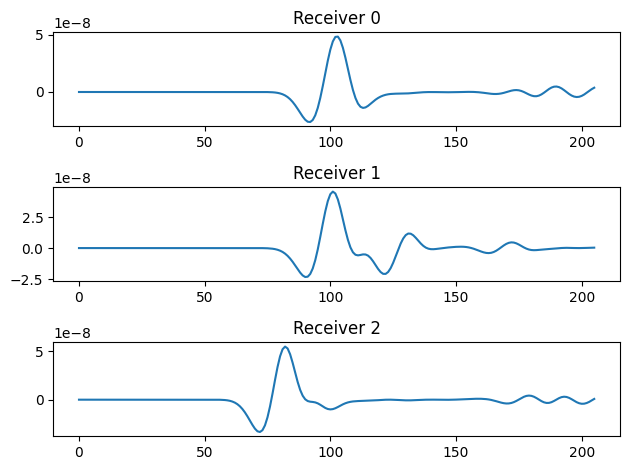

In [274]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1)

for i, ax in enumerate(axs):
    ax.plot(obs[:, i])
    ax.set_title(f"Receiver {i}")

fig.tight_layout()

Finally, we can use the `wavefield`'s `.animate` utility to render a gif of the amplitude history over time.

In [275]:
outfile = result.wf.animate(filename="example-solve.gif")